In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ['GOOGLE_API_KEY'] = os.getenv('GOOGLE_API_KEY')
os.environ['HF_TOKEN'] = os.getenv('HUGGINGFACE_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

In [3]:
def function_1(input_1):
    return input_1 + " First Function "

def function_2(input_2):
    return input_2 + "to Second Function"

In [55]:
from langgraph.graph import StateGraph
from typing import TypedDict

# Define the state
class State(TypedDict):
    input: str
    output: str

# Create a StateGraph
workflow1 = StateGraph(State)

# Add nodes (updated to accept state parameter)
def node_1_updated(state):
    result = state["input"] + " First Function "
    return {"output": result}

def node_2_updated(state):
    result = state["output"] + "to Second Function"
    return {"output": result}

workflow1.add_node("node_1", node_1_updated)
workflow1.add_node("node_2", node_2_updated)

workflow1.add_edge('node_1', 'node_2')

workflow1.set_entry_point("node_1")
workflow1.set_finish_point("node_2")

app1 = workflow1.compile()


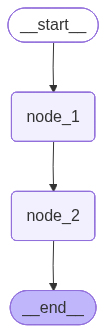

In [ ]:
from IPython.display import display
display(app1)

In [39]:
app1.invoke({"input": "Hello,"})

{'input': 'Hello,', 'output': 'Hello, First Function to Second Function'}

In [38]:
app1.invoke({"input": "Hello,"})['output']

'Hello, First Function to Second Function'

In [40]:
input = "Hello,"

In [44]:
for output in app1.stream({"input": input}):
    for key,value in output.items():
        print(f"{key}: {value}")

node_1: {'output': 'Hello, First Function '}
node_2: {'output': 'Hello, First Function to Second Function'}


### Now Workflow wit LLM

In [2]:
from langchain_huggingface import HuggingFaceEmbeddings
embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

c:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4876.44it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [46]:
def node_1_new1(state):
    llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
    result = llm.invoke(state["input"]).content
    return {"output": result}

In [47]:
def node_2_new2(state):
    res = state["output"].upper()
    return {"output": res}

In [48]:
workflow2 = StateGraph(State)
workflow2.add_node("llm", node_1_new1)
workflow2.add_node("UPPER", node_2_new2)

workflow2.add_edge('llm', 'UPPER')

workflow2.set_entry_point("llm")
workflow2.set_finish_point("UPPER")

In [49]:
app2 = workflow2.compile()

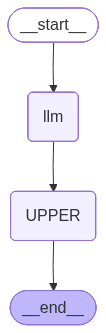

In [50]:
display(app2)

In [51]:
input2 = "Tell About Economic Growth in India"

In [52]:
app2.invoke({"input": input2})

{'input': 'Tell About Economic Growth in India',
 'output': 'INDIA\'S ECONOMIC GROWTH STORY IS ONE OF THE MOST DYNAMIC AND SIGNIFICANT IN THE GLOBAL ECONOMY. OVER THE PAST FEW DECADES, IT HAS TRANSFORMED FROM A LARGELY AGRARIAN, SOCIALIST-LEANING ECONOMY TO A FAST-GROWING, MARKET-ORIENTED POWERHOUSE.\n\nHERE\'S A BREAKDOWN OF KEY ASPECTS OF INDIA\'S ECONOMIC GROWTH:\n\n## THE TRANSFORMATION: FROM "HINDU RATE OF GROWTH" TO GLOBAL PLAYER\n\n*   **PRE-1991:** FOR DECADES AFTER INDEPENDENCE, INDIA\'S ECONOMY GREW AT A SLOW PACE, OFTEN TERMED THE "HINDU RATE OF GROWTH" (AROUND 3-4% ANNUALLY). THIS WAS LARGELY DUE TO PROTECTIONIST POLICIES, STATE-LED INDUSTRIALIZATION, AND A COMPLEX LICENSE RAJ.\n*   **POST-1991 LIBERALIZATION:** THE ECONOMIC REFORMS INITIATED IN 1991 MARKED A WATERSHED MOMENT. THESE REFORMS INCLUDED OPENING UP THE ECONOMY TO FOREIGN INVESTMENT, REDUCING TARIFFS, PRIVATIZING STATE-OWNED ENTERPRISES, AND DEREGULATING INDUSTRIES. THIS UNLEASHED INDIA\'S ECONOMIC POTENTIAL.\n\n

In [53]:
for output in app2.stream({"input": input2}):
    for key,value in output.items():
        print(f"{key}: {value}")

llm: {'output': 'India\'s economic growth story is one of the most remarkable transformations in recent global history. From a largely agrarian, socialist-leaning economy struggling with slow growth for decades, it has emerged as one of the world\'s fastest-growing major economies and a significant global player.\n\nHere\'s a breakdown of India\'s economic growth:\n\n## 1. The Pre-Liberalization Era (Pre-1991): The "Hindu Rate of Growth"\n\nBefore 1991, India\'s economy was characterized by:\n*   **Centralized Planning:** A socialist-inspired model with significant state control.\n*   **Protectionism:** High tariffs and import restrictions to protect domestic industries.\n*   **License Raj:** Bureaucratic hurdles and extensive licensing requirements that stifled private enterprise.\n*   **Slow Growth:** Often referred to as the "Hindu Rate of Growth," averaging around 3-4% annually, which was barely above population growth, leading to limited improvements in living standards.\n*   **Fo

### Including RAG Pipeline 

In [5]:
# %pip install -q langchain-text-splitters

from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma

In [69]:
if os.path.exists("DATA/"):
    print("Directory exists")

Directory exists


In [ ]:
# load only lamma3.txt file from DATA/
loader = DirectoryLoader('DATA/', glob="./lamma3.txt", loader_cls=TextLoader, loader_kwargs={"autodetect_encoding": True})
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=250,
    chunk_overlap=20,
    length_function=len
)
new_docs = text_splitter.split_documents(documents=docs)
doc_strings = [doc.page_content for doc in new_docs]

In [72]:
embedding

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [73]:
db = Chroma.from_documents(new_docs, embedding)
retriever = db.as_retriever(search_kwargs={"k": 4})

In [75]:
query = "Tell me about llama3?"
docs = retriever.invoke(query)
print(docs)

[Document(metadata={'source': 'DATA\\llama3.txt'}, page_content='of Llama 3 as being "surprisingly capable" given it\'s size.[11]'), Document(metadata={'source': 'DATA\\llama3.txt'}, page_content='some commercial use.[6][7] Llama models are trained at different parameter sizes, typically ranging between 7B and 70B.[4] Originally, Llama was only available as a foundation model.[8] Starting with Llama 2, Meta AI started releasing instruction'), Document(metadata={'source': 'DATA\\llama3.txt'}, page_content='Model weights for the first version of Llama were released to the research community under a non-commercial license.[5][3] Subsequent versions of Llama were made accessible outside academia and released under licenses that permitted some commercial'), Document(metadata={'source': 'DATA\\llama3.txt'}, page_content='Llama (Large Language Model Meta AI) is a family of autoregressive large language models released by Meta AI starting in February 2023.[2][3] The latest version is Llama 3 r

In [4]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
# from langchain.chains import RetrievalQA

In [93]:
# Updated version with latest LangGraph API
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph
import operator

# Define the AgentState with proper typing
class AgentState(TypedDict):
    messages: Annotated[list, operator.add]  # Messages will accumulate

# Node 1: Route/Classify the query
def agent_node(state: AgentState) -> AgentState:
    """LLM node to classify the query topic"""
    messages = state['messages']
    question = messages[0]  # Get the user question
    
    complete_query = ("Your task is to provide only the topic based on the user query and then just reframe the question for RAG retrieval. "
                     "Don't include reasoning. "
                     f"Following is the user query: {question}")
    
    response = llm.invoke(complete_query)
    
    # Return updated state with messages
    return {"messages": [response.content]}

# Node 2: Retrieve and answer using RAG
def tool_node(state: AgentState) -> AgentState:
    """RAG node to answer based on retrieved context"""
    messages = state['messages']
    question = messages[0]  # Get the original question
    
    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)
    
    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )
    
    result = retrieval_chain.invoke(question)
    return {"messages": [result]}

# Create StateGraph with proper state
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("Agent", agent_node)
workflow.add_node("Tool", tool_node)

# Add edges
workflow.add_edge('Agent', 'Tool')

# Set entry and finish points
workflow.set_entry_point("Agent")
workflow.set_finish_point("Tool")

# Compile the app
app4 = workflow.compile()


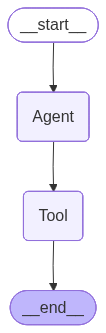

In [83]:
display(app4)

In [85]:
inputs = {"messages": ["Tell me about llama3 model"]}
result = app4.invoke(inputs)
print("Final messages:", result['messages'])

Final messages: ['Tell me about llama3 model', 'LLaMA 3 Model', 'Llama 3 70B beats Gemini and Claude in most benchmarks. The 8B parameter version of Llama 3 is described by Wired as "surprisingly capable" given its size.']


In [94]:
for output in app4.stream(inputs):
    for key,value in output.items():
        print(f"{key}: {value}")

Agent: {'messages': ['Topic: Llama 3 Model\nQuestion for RAG: What are the key characteristics, capabilities, and technical details of the Llama 3 model?']}
Tool: {'messages': ['The Llama 3 70B model beats Gemini and Claude in most benchmarks. Wired describes the 8B parameter version of Llama 3 as "surprisingly capable" given its size.']}


# Understanding LangGraph State Types

## Core Typing Concepts

### **TypedDict**
`TypedDict` is a special type that allows you to define a dictionary in Python where each key has a specific type. It's useful when you want to enforce type checks on the keys and values of a dictionary.

```python
class MyState(TypedDict):
    messages: list
    topic: str
```

### **Annotated**
`Annotated` is used to add metadata or constraints to a type. It's typically used for adding additional information, like constraints or descriptions, to the type.

```python
messages: Annotated[list, operator.add]  # Metadata: use operator.add for concatenation
```

---

## LangChain Message Types

### **Sequence[BaseMessage]**
`Sequence` is a generic type from Python's typing module that represents a list-like structure (such as a list or tuple) where the order matters, and you can access elements by their position.

### **BaseMessage**
From the LangChain framework, `BaseMessage` is part of its core messaging system. It is typically used when handling or processing messages in LangChain's workflows.

### **operator.add**
`operator.add` is a function from Python's operator module that performs addition (+) on its arguments. In this context, it's being used as metadata for the `Annotated` type, suggesting that the sequence of `BaseMessage` objects is meant to be "added" or concatenated with another sequence. It's an indicator of how the messages field will be treated in your program logic.

---

## Pydantic Validation

### **TopicSelectionParser**
A Pydantic model that defines two fields (`Topic` and `Reasoning`), both of which are required to be strings.

### **Field**
Adds metadata, like descriptions, and can also be used for validation and constraints on Pydantic fields.

### **Pydantic's Role**
Ensures that the data matches the expected structure and types, raising validation errors if the data is invalid.

---

## Putting It All Together

The line `messages: Annotated[Sequence[BaseMessage], operator.add]` defines a field `messages` that:

- ✅ Must be a sequence (like a list or tuple) of `BaseMessage` objects
- ✅ Has the additional annotation `operator.add`, which suggests this sequence is intended to support addition (i.e., concatenation of multiple sequences of messages)
- ✅ Will accumulate/merge when used in LangGraph workflows

### Example Usage:
```python
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

# State with messages:
state = {
    "messages": [
        BaseMessage("Hello!", "Alice"), 
        BaseMessage("Hi!", "Bob")
    ]
}

# When using operator.add, new messages get concatenated
# state["messages"] += [BaseMessage("Hey!", "Charlie")]
```

## ---
## ---
## Including a router or branch in Graph

In [15]:
loader2 = DirectoryLoader('DATA/', glob="./japan.txt", loader_cls=TextLoader, loader_kwargs={"autodetect_encoding": True})

docs2=loader2.load()

text_splitter2 = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=50
)

new_docs2 = text_splitter2.split_documents(documents=docs2)
doc_strings2 = [doc.page_content for doc in new_docs2]

In [19]:
db2 = Chroma.from_documents(new_docs2, embedding)
retriever2 = db2.as_retriever(search_kwargs={"k": 4})

In [27]:
query = "Tell me about Japan's Key Growth Drivers?"

docs = retriever2.invoke(query)

In [30]:
from typing import TypedDict, Annotated, Sequence
import operator
from langchain_core.messages import BaseMessage
from langchain_core.prompts import PromptTemplate

In [31]:
class AgentState(TypedDict):
    # The 'messages' field should be a sequence of strings, and we annotate it with 'operator.add'
    # This implies we might want to "add" new messages to the sequence later
    messages: Annotated[Sequence[BaseMessage], operator.add]
    
    
from pydantic import BaseModel , Field
class TopicSelectionParser(BaseModel):
    Topic: str = Field(description='Selected Topic')
    Reasoning: str = Field(description='Reasoning behind topic selection')

In [33]:
# %pip install -q langchain-core
from langchain_core.output_parsers import PydanticOutputParser
parser = PydanticOutputParser(pydantic_object=TopicSelectionParser)

In [34]:
print(parser.get_format_instructions())

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"Topic": {"description": "Selected Topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}
```


In [41]:
template="""
    Your task is to classify the given user query into one of the following categories: [Japan, Not Related]. 
    Only respond with the category name and nothing else.

    User query: "Tell me about Japan's Industrial Growth"
    The output should be formatted as a JSON instance that conforms to the JSON schema below.

    As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
    the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

    Here is the output schema:
    ```
    {"properties": {"Topic": {"description": "Selected Topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}
        """

In [42]:
def function_1(state):
    message=state["messages"]
    question=message[-1]
    print(question)
    
    template="""
    Your task is to classify the given user query into one of the following categories: [Japan, Not Related]. 
    Only respond with the category name and nothing else.

    User query: {question}
    {format_instructions}
    """
    
    prompt = PromptTemplate(template=template,
                                    input_variables=[question],
                                    partial_variables={
                                        "format_instructions" : parser.get_format_instructions()                                    }
                                    )
    chain =  prompt | llm | parser
    
    response = chain.invoke({"question":question,"format_instructions" : parser.get_format_instructions() })

    print(response)

    return {"messages": [response.Topic]}

In [43]:
state={"messages": ["Tell me about India's Industrial Growth"]}

In [44]:
function_1(state)

Tell me about India's Industrial Growth
Topic='Not Related' Reasoning="The user query is about 'India's Industrial Growth', which is a topic related to India, not Japan. Therefore, it falls under the 'Not Related' category based on the provided options."


{'messages': ['Not Related']}

In [69]:
def function_2(state):
    print('-> Calling RAG ->')
    messages = state['messages']
    question = messages[0] ## Fetching the user question
    print(question)

    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)
    
    print(prompt)

    retrieval_chain = (
        {"context": retriever2, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
        )
    result = retrieval_chain.invoke(question)
    return  {"messages": [result]}

In [48]:
state1 =  {"messages": ["Japan"]}

In [ ]:
function_2({'messages': ['Japan']})

In [54]:
def function_3(state):
    print('-> Calling LLM ->')

    messages = state['messages']
    question = messages[0] ## Fetching the user question

    # Normal LLM call
    complete_query = "Answer the following question with your knowledge of the real world. Following is the user question: " + question
    response = llm.invoke(complete_query)
    return {"messages": [response.content]}

In [61]:
def router(state):
    print('-> Router ->')
    
    messages = state["messages"]
    last_message = messages[-1]
    print(last_message)
    if 'Japan' in last_message:
        return 'RAG Call'
    else:
        return 'LLM Call'

In [70]:
from langgraph.graph import StateGraph,END

workflow5 = StateGraph(AgentState) ### StateGraph with AgentState
workflow5.add_node("agent", function_1)
workflow5.add_node("RAG", function_2)
workflow5.add_node("LLM", function_3)
workflow5.set_entry_point("agent")

workflow5.add_conditional_edges(
    "agent",
    router,
    {
        "RAG Call": "RAG",
        "LLM Call": "LLM",
    }
)

workflow5.add_edge("RAG",END)
workflow5.add_edge("LLM",END)
app5=workflow5.compile()

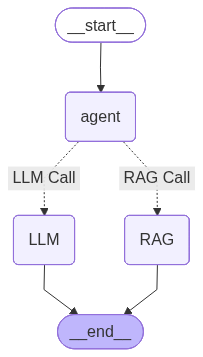

In [57]:
display(app5)

In [67]:
inputs5 = {"messages": ["Tell me about Japan's Industrial Growth"]}

In [71]:
output5 = app5.invoke(inputs5)

Tell me about Japan's Industrial Growth
Topic='Japan' Reasoning="The user query explicitly mentions 'Japan' and asks for information about 'Japan's Industrial Growth', directly relating to the country."
-> Router ->
Japan
-> Calling RAG ->
Tell me about Japan's Industrial Growth
input_variables=['context', 'question'] input_types={} partial_variables={} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n    {context}\n\n    Question: {question}\n    '), additional_kwargs={})]


In [72]:
# from pprint import pprint

pprint(output5)

{'messages': ["Tell me about Japan's Industrial Growth",
              'Japan',
              "The industrial sector contributes approximately 27% of Japan's "
              'GDP. The provided context also indicates "Industrial Growth & '
              'Production" as a topic.']}
